# CELL 1: Install & Import Dependencies

In [ ]:
!pip install kagglehub -q

import kagglehub, os, shutil, random, numpy as np, matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)
from tensorflow.keras.optimizers import Adam

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# CELL 2: Download Dataset

In [ ]:
path = kagglehub.dataset_download("orvile/simple-vs-comminuted-fractures-x-ray-data")
print("Dataset path:", path)

# Explore folder structure
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 3:
        for f in files[:3]:
            print(f"{'  ' * (level+1)}{f}")

100%|██████████| 1.96G/1.96G [00:17<00:00, 118MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/orvile/simple-vs-comminuted-fractures-x-ray-data/versions/2
2/
  dataset.csv
  Bone Fracture X-ray Dataset Simple vs. Comminuted Fractures/
    Bone Fracture X-ray Dataset Simple vs. Comminuted Fractures/
      Bone Fracture/
        Bone Fracture/
          Augmented/
            Comminuted Bone Fracture/
            Simple Bone Fracture/
          Orginal/
            Comminuted Bone Fracture/
            Simple Bone Fracture/


# CELL 3: Locate Class Folders & Build Dataset Path

In [ ]:

BASE_DIR = path

def find_class_dirs(base):

    for root, dirs, _ in os.walk(base):
        lower_dirs = [d.lower() for d in dirs]
        if any('simple' in d for d in lower_dirs) and any('comminuted' in d for d in lower_dirs):
            return root
    return base

DATA_ROOT = find_class_dirs(BASE_DIR)
print("Data root detected:", DATA_ROOT)
print("Contents:", os.listdir(DATA_ROOT))

Data root detected: /root/.cache/kagglehub/datasets/orvile/simple-vs-comminuted-fractures-x-ray-data/versions/2
Contents: ['dataset.csv', 'Bone Fracture X-ray Dataset Simple vs. Comminuted Fractures']


# CELL 4: Configuration

In [ ]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 30
LR         = 1e-4
SEED       = 42
MODEL_NAME = "ResNet50"

CLASS_NAMES = ['simple', 'comminuted']

# CELL 5: Create Train / Val / Test Split

In [ ]:
import glob, os, shutil
from sklearn.model_selection import train_test_split
print("Exact contents of DATA_ROOT:")
for item in os.listdir(DATA_ROOT):
    full = os.path.join(DATA_ROOT, item)
    if os.path.isdir(full):
        count = len(glob.glob(f"{full}/**/*.*", recursive=True))
        print(f"   '{item}'  →  {count} files")
    else:
        print(f"   '{item}'")

Exact contents of DATA_ROOT:
   'Comminuted Bone Fracture'  →  7366 files
   'Simple Bone Fracture'  →  6311 files


In [ ]:
import os, glob, shutil
from sklearn.model_selection import train_test_split

BASE = '/root/.cache/kagglehub/datasets/orvile/simple-vs-comminuted-fractures-x-ray-data/versions/2'


AUG_DIR  = None
ORIG_DIR = None

for root, dirs, files in os.walk(BASE):
    for d in dirs:
        d_lower = d.lower()
        if d_lower == 'augmented':
            AUG_DIR = os.path.join(root, d)
            print(f" Augmented found: {AUG_DIR}")
        if d_lower in ('orignal', 'original'):   # handles dataset typo
            ORIG_DIR = os.path.join(root, d)
            print(f" Original found:  {ORIG_DIR}")

print(f"\nAUG_DIR  = '{AUG_DIR}'")
print(f"ORIG_DIR = '{ORIG_DIR}'")


DATA_ROOT = AUG_DIR if AUG_DIR is not None else ORIG_DIR
assert DATA_ROOT is not None, " Neither Augmented nor Original folder found! Check BASE path."

print(f"\n Using DATA_ROOT: {DATA_ROOT}")
print("Contents:")
for item in sorted(os.listdir(DATA_ROOT)):
    full = os.path.join(DATA_ROOT, item)
    if os.path.isdir(full):
        n = len(glob.glob(f"{full}/**/*.*", recursive=True))
        print(f"   '{item}'  →  {n} files")


CLASS_NAMES = []
for item in sorted(os.listdir(DATA_ROOT)):
    if os.path.isdir(os.path.join(DATA_ROOT, item)):
        CLASS_NAMES.append(item)

print(f"\n Detected CLASS_NAMES: {CLASS_NAMES}")
assert len(CLASS_NAMES) == 2, f" Expected 2 class folders, found: {CLASS_NAMES}"


WORK_DIR = "/content/fracture_split"

if os.path.exists(WORK_DIR):
    shutil.rmtree(WORK_DIR)
    print(f"\n  Cleared old split at {WORK_DIR}")

for split in ['train', 'val', 'test']:
    for cls in CLASS_NAMES:
        os.makedirs(f"{WORK_DIR}/{split}/{cls}", exist_ok=True)

print(f" Created split directories under {WORK_DIR}")


def populate_split(data_root, work_dir, class_names, seed=42):
    for cls in class_names:
        cls_dir = os.path.join(data_root, cls)

        if not os.path.isdir(cls_dir):
            print(f"  Folder not found: {cls_dir}")
            continue

        images = (glob.glob(os.path.join(cls_dir, '**', '*.jpg'),  recursive=True) +
                  glob.glob(os.path.join(cls_dir, '**', '*.jpeg'), recursive=True) +
                  glob.glob(os.path.join(cls_dir, '**', '*.png'),  recursive=True))

        if len(images) == 0:
            print(f"  No images found in: {cls_dir}")
            continue

        print(f"\n  Class '{cls}': {len(images)} images found")

        train_imgs, temp      = train_test_split(images, test_size=0.2, random_state=seed)
        val_imgs,   test_imgs = train_test_split(temp,   test_size=0.5, random_state=seed)

        for imgs, split in [(train_imgs, 'train'), (val_imgs, 'val'), (test_imgs, 'test')]:
            for src in imgs:
                dst = os.path.join(work_dir, split, cls, os.path.basename(src))
                shutil.copy2(src, dst)

        print(f"    → train: {len(train_imgs)}  |  val: {len(val_imgs)}  |  test: {len(test_imgs)}")

print("\n Populating splits...")
populate_split(DATA_ROOT, WORK_DIR, CLASS_NAMES)


TRAIN_DIR = f"{WORK_DIR}/train"
VAL_DIR   = f"{WORK_DIR}/val"
TEST_DIR  = f"{WORK_DIR}/test"


print("\n Final split verification:")
total = 0
for split in ['train', 'val', 'test']:
    for cls in CLASS_NAMES:
        n = len(glob.glob(f"{WORK_DIR}/{split}/{cls}/**/*.*", recursive=True))
        total += n
        print(f"  {split:5s} / {cls:15s} : {n} images")

print(f"\n  Total images copied: {total}")
assert total > 0, " No images were copied! Check DATA_ROOT and CLASS_NAMES."


 Augmented found: /root/.cache/kagglehub/datasets/orvile/simple-vs-comminuted-fractures-x-ray-data/versions/2/Bone Fracture X-ray Dataset Simple vs. Comminuted Fractures/Bone Fracture X-ray Dataset Simple vs. Comminuted Fractures/Bone Fracture/Bone Fracture/Augmented

AUG_DIR  = '/root/.cache/kagglehub/datasets/orvile/simple-vs-comminuted-fractures-x-ray-data/versions/2/Bone Fracture X-ray Dataset Simple vs. Comminuted Fractures/Bone Fracture X-ray Dataset Simple vs. Comminuted Fractures/Bone Fracture/Bone Fracture/Augmented'
ORIG_DIR = 'None'

 Using DATA_ROOT: /root/.cache/kagglehub/datasets/orvile/simple-vs-comminuted-fractures-x-ray-data/versions/2/Bone Fracture X-ray Dataset Simple vs. Comminuted Fractures/Bone Fracture X-ray Dataset Simple vs. Comminuted Fractures/Bone Fracture/Bone Fracture/Augmented
Contents:
   'Comminuted Bone Fracture'  →  7366 files
   'Simple Bone Fracture'  →  6311 files

 Detected CLASS_NAMES: ['Comminuted Bone Fracture', 'Simple Bone Fracture']

  Clear

# CELL 6: Data Generators

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    vertical_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', seed=SEED
)
val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', seed=SEED, shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', seed=SEED, shuffle=False
)

print("\nClass indices:", train_gen.class_indices)

Found 10940 images belonging to 2 classes.
Found 1368 images belonging to 2 classes.
Found 1369 images belonging to 2 classes.

Class indices: {'Comminuted Bone Fracture': 0, 'Simple Bone Fracture': 1}


# CELL 7: Visualise Sample Images

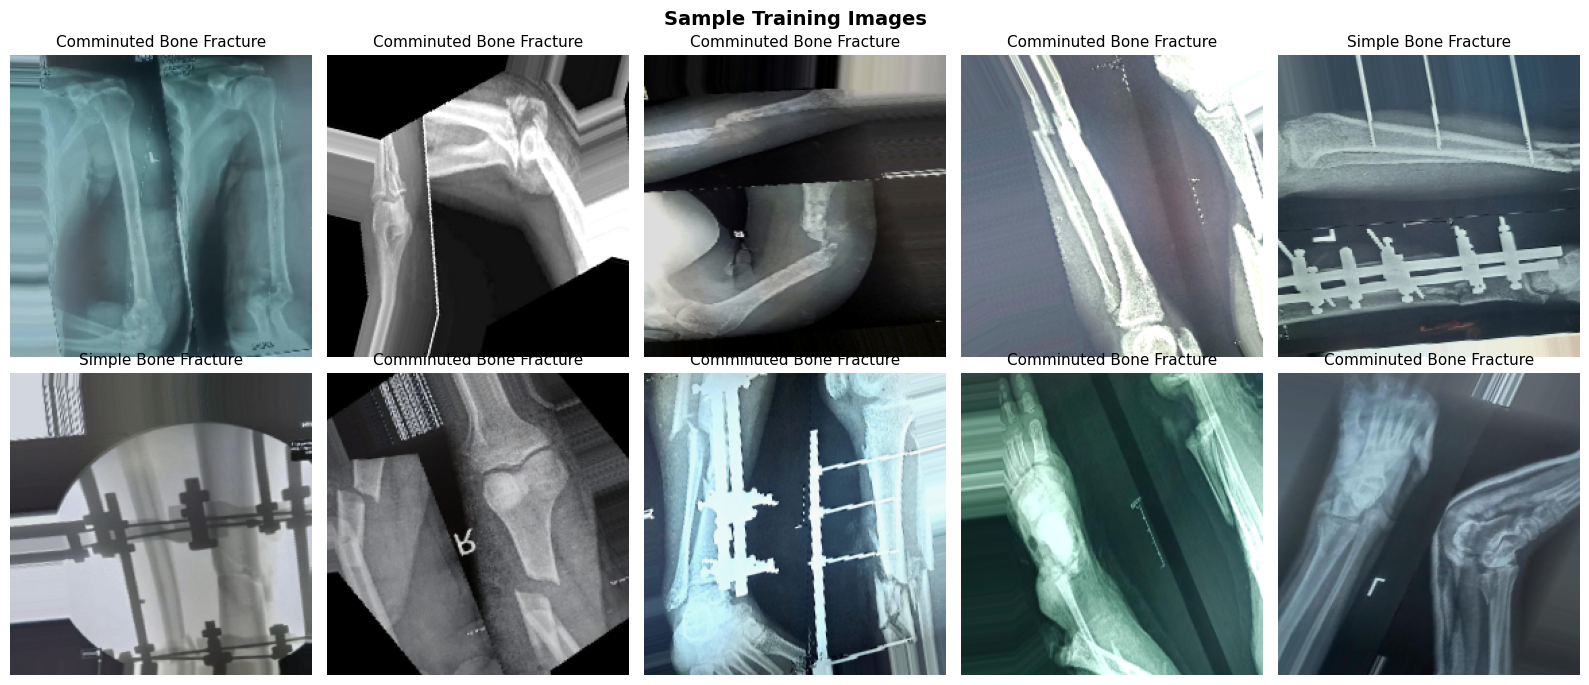

In [ ]:
imgs, labels = next(train_gen)
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
label_map = {v: k for k, v in train_gen.class_indices.items()}

for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i])
    ax.set_title(f"{label_map[int(round(labels[i]))]}", fontsize=11)
    ax.axis('off')

plt.suptitle("Sample Training Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# CELL 8: Build Model

In [ ]:
def build_model(name="ResNet50", input_shape=(224, 224, 3), dropout=0.5):
    inp = layers.Input(shape=input_shape)

    if name == "ResNet50":
        base = ResNet50(include_top=False, weights='imagenet', input_tensor=inp)
    elif name == "VGG16":
        base = VGG16(include_top=False,   weights='imagenet', input_tensor=inp)
    else:
        raise ValueError("MODEL_NAME must be 'ResNet50' or 'VGG16'")

    # Freeze pretrained backbone initially
    base.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(dropout / 2)(x)
    out = layers.Dense(1, activation='sigmoid')(x)   # Binary classification

    model = models.Model(inputs=inp, outputs=out)
    return model, base

model, base_model = build_model(MODEL_NAME)

model.compile(
    optimizer=Adam(learning_rate=LR),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,153,473 (92.14 MB)

 Trainable params: 561,665 (2.14 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

# CELL 9: Callbacks

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_auc', patience=7, restore_best_weights=True,
                  mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3,
                      min_lr=1e-7, verbose=1),
    ModelCheckpoint('/content/best_model.h5', monitor='val_auc',
                    save_best_only=True, mode='max', verbose=1)
]

print(callbacks)

[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x7da5f5a3ce90>, <keras.src.callbacks.reduce_lr_on_plateau.ReduceLROnPlateau object at 0x7da623fe5760>, <keras.src.callbacks.model_checkpoint.ModelCheckpoint object at 0x7da623fe5e50>]


# CELL 10: Phase 1 — Train Head Only

In [ ]:
print("PHASE 1: Training classification head (backbone frozen)")
history1 = model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

PHASE 1: Training classification head (backbone frozen)
Epoch 1/15
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - accuracy: 0.5353 - auc: 0.5425 - loss: 0.7608 - precision: 0.4940 - recall: 0.3401
Epoch 1: val_auc improved from None to 0.64246, saving model to /content/best_model.h5



Epoch 1: finished saving model to /content/best_model.h5
342/342 ━━━━━━━━━━━━━━━━━━━━ 274s 751ms/step - accuracy: 0.5427 - auc: 0.5551 - loss: 0.7503 - precision: 0.5060 - recall: 0.3736 - val_accuracy: 0.5680 - val_auc: 0.6425 - val_loss: 0.7277 - val_precision: 0.5188 - val_recall: 0.8764 - learning_rate: 1.0000e-04
Epoch 2/15
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - accuracy: 0.5580 - auc: 0.5792 - loss: 0.7310 - precision: 0.5301 - recall: 0.4714
Epoch 2: val_auc improved from 0.64246 to 0.66260, saving model to /content/best_model.h5



Epoch 2: finished saving model to /content/best_model.h5
342/342 ━━━━━━━━━━━━━━━━━━━━ 235s 688ms/step - accuracy: 0.5610 - auc: 0.5875 - loss: 0.7264 - precision: 0.5294 - recall: 0.4370 - val_accuracy: 0.6111 - val_auc: 0.6626 - val_loss: 0.6979 - val_precision: 0.5772 - val_recall: 0.5864 - learning_rate: 1.0000e-04
Epoch 3/15
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.5628 - auc: 0.5923 - loss: 0.7208 - precision: 0.5291 - recall: 0.4336
Epoch 3: val_auc improved from 0.66260 to 0.67936, saving model to /content/best_model.h5



Epoch 3: finished saving model to /content/best_model.h5
342/342 ━━━━━━━━━━━━━━━━━━━━ 236s 688ms/step - accuracy: 0.5656 - auc: 0.5970 - loss: 0.7187 - precision: 0.5352 - recall: 0.4463 - val_accuracy: 0.6287 - val_auc: 0.6794 - val_loss: 0.6874 - val_precision: 0.5802 - val_recall: 0.7052 - learning_rate: 1.0000e-04
Epoch 4/15
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - accuracy: 0.5842 - auc: 0.6172 - loss: 0.7108 - precision: 0.5663 - recall: 0.4755
Epoch 4: val_auc improved from 0.67936 to 0.68200, saving model to /content/best_model.h5



Epoch 4: finished saving model to /content/best_model.h5
342/342 ━━━━━━━━━━━━━━━━━━━━ 234s 684ms/step - accuracy: 0.5814 - auc: 0.6170 - loss: 0.7081 - precision: 0.5554 - recall: 0.4647 - val_accuracy: 0.6265 - val_auc: 0.6820 - val_loss: 0.6858 - val_precision: 0.5769 - val_recall: 0.7132 - learning_rate: 1.0000e-04
Epoch 5/15
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 649ms/step - accuracy: 0.5776 - auc: 0.6114 - loss: 0.7078 - precision: 0.5482 - recall: 0.4837
Epoch 5: val_auc improved from 0.68200 to 0.69234, saving model to /content/best_model.h5



Epoch 5: finished saving model to /content/best_model.h5
342/342 ━━━━━━━━━━━━━━━━━━━━ 235s 686ms/step - accuracy: 0.5813 - auc: 0.6161 - loss: 0.7068 - precision: 0.5546 - recall: 0.4699 - val_accuracy: 0.6352 - val_auc: 0.6923 - val_loss: 0.6757 - val_precision: 0.5853 - val_recall: 0.7179 - learning_rate: 1.0000e-04
Epoch 6/15
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 676ms/step - accuracy: 0.5789 - auc: 0.6200 - loss: 0.7047 - precision: 0.5584 - recall: 0.5005
Epoch 6: val_auc improved from 0.69234 to 0.70126, saving model to /content/best_model.h5



Epoch 6: finished saving model to /content/best_model.h5
342/342 ━━━━━━━━━━━━━━━━━━━━ 244s 713ms/step - accuracy: 0.5760 - auc: 0.6202 - loss: 0.7041 - precision: 0.5456 - recall: 0.4844 - val_accuracy: 0.6411 - val_auc: 0.7013 - val_loss: 0.6744 - val_precision: 0.6000 - val_recall: 0.6656 - learning_rate: 1.0000e-04
Epoch 7/15
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 769ms/step - accuracy: 0.5849 - auc: 0.6264 - loss: 0.7017 - precision: 0.5600 - recall: 0.4982
Epoch 7: val_auc did not improve from 0.70126
342/342 ━━━━━━━━━━━━━━━━━━━━ 276s 806ms/step - accuracy: 0.5870 - auc: 0.6266 - loss: 0.7013 - precision: 0.5589 - recall: 0.4980 - val_accuracy: 0.6455 - val_auc: 0.7012 - val_loss: 0.6722 - val_precision: 0.5961 - val_recall: 0.7179 - learning_rate: 1.0000e-04
Epoch 8/15
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 649ms/step - accuracy: 0.5929 - auc: 0.6311 - loss: 0.6969 - precision: 0.5604 - recall: 0.5083
Epoch 8: val_auc improved from 0.70126 to 0.71181, saving model to /content/best_model.h5



Epoch 8: finished saving model to /content/best_model.h5
342/342 ━━━━━━━━━━━━━━━━━━━━ 234s 685ms/step - accuracy: 0.5931 - auc: 0.6351 - loss: 0.6959 - precision: 0.5645 - recall: 0.5176 - val_accuracy: 0.6674 - val_auc: 0.7118 - val_loss: 0.6647 - val_precision: 0.6205 - val_recall: 0.7179 - learning_rate: 1.0000e-04
Epoch 9/15
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.5973 - auc: 0.6456 - loss: 0.6906 - precision: 0.5709 - recall: 0.5270
Epoch 9: val_auc did not improve from 0.71181
342/342 ━━━━━━━━━━━━━━━━━━━━ 235s 686ms/step - accuracy: 0.5976 - auc: 0.6411 - loss: 0.6929 - precision: 0.5689 - recall: 0.5281 - val_accuracy: 0.6535 - val_auc: 0.7113 - val_loss: 0.6630 - val_precision: 0.6000 - val_recall: 0.7464 - learning_rate: 1.0000e-04
Epoch 10/15
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - accuracy: 0.6052 - auc: 0.6472 - loss: 0.6901 - precision: 0.5787 - recall: 0.5697
Epoch 10: val_auc improved from 0.71181 to 0.71908, saving model to /content/best_model.h5



Epoch 10: finished saving model to /content/best_model.h5
342/342 ━━━━━━━━━━━━━━━━━━━━ 231s 676ms/step - accuracy: 0.6059 - auc: 0.6472 - loss: 0.6891 - precision: 0.5765 - recall: 0.5501 - val_accuracy: 0.6601 - val_auc: 0.7191 - val_loss: 0.6580 - val_precision: 0.6119 - val_recall: 0.7195 - learning_rate: 1.0000e-04
Epoch 11/15
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - accuracy: 0.6054 - auc: 0.6477 - loss: 0.6893 - precision: 0.5730 - recall: 0.5321
Epoch 11: val_auc did not improve from 0.71908
342/342 ━━━━━━━━━━━━━━━━━━━━ 230s 671ms/step - accuracy: 0.6012 - auc: 0.6442 - loss: 0.6906 - precision: 0.5713 - recall: 0.5436 - val_accuracy: 0.6594 - val_auc: 0.7174 - val_loss: 0.6545 - val_precision: 0.6147 - val_recall: 0.7005 - learning_rate: 1.0000e-04
Epoch 12/15
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - accuracy: 0.6087 - auc: 0.6467 - loss: 0.6882 - precision: 0.5788 - recall: 0.5557
Epoch 12: val_auc did not improve from 0.71908
342/342 ━━━━━━━━━━━━━━━━━━━━ 231s 676ms/s

# CELL 11: Phase 2 — Fine-Tune Top Layers

In [ ]:
print("PHASE 2: Fine-tuning top layers of backbone")

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=LR / 10),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

history2 = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

PHASE 2: Fine-tuning top layers of backbone
Epoch 1/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - accuracy: 0.5485 - auc: 0.5698 - loss: 0.7768 - precision: 0.5253 - recall: 0.4213
Epoch 1: val_auc did not improve from 0.71908
342/342 ━━━━━━━━━━━━━━━━━━━━ 283s 763ms/step - accuracy: 0.5628 - auc: 0.5860 - loss: 0.7525 - precision: 0.5303 - recall: 0.4588 - val_accuracy: 0.6104 - val_auc: 0.6700 - val_loss: 0.6773 - val_precision: 0.5628 - val_recall: 0.6957 - learning_rate: 1.0000e-05
Epoch 2/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.5835 - auc: 0.6161 - loss: 0.7193 - precision: 0.5483 - recall: 0.5077
Epoch 2: val_auc did not improve from 0.71908
342/342 ━━━━━━━━━━━━━━━━━━━━ 240s 701ms/step - accuracy: 0.5835 - auc: 0.6180 - loss: 0.7195 - precision: 0.5520 - recall: 0.5172 - val_accuracy: 0.6338 - val_auc: 0.6990 - val_loss: 0.6575 - val_precision: 0.5844 - val_recall: 0.7132 - learning_rate: 1.0000e-05
Epoch 3/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accu


Epoch 4: finished saving model to /content/best_model.h5
342/342 ━━━━━━━━━━━━━━━━━━━━ 237s 694ms/step - accuracy: 0.5977 - auc: 0.6446 - loss: 0.6968 - precision: 0.5643 - recall: 0.5628 - val_accuracy: 0.6711 - val_auc: 0.7286 - val_loss: 0.6451 - val_precision: 0.6259 - val_recall: 0.7132 - learning_rate: 3.0000e-06
Epoch 5/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - accuracy: 0.6136 - auc: 0.6618 - loss: 0.6865 - precision: 0.5889 - recall: 0.5825
Epoch 5: val_auc improved from 0.72862 to 0.72933, saving model to /content/best_model.h5



Epoch 5: finished saving model to /content/best_model.h5
342/342 ━━━━━━━━━━━━━━━━━━━━ 239s 699ms/step - accuracy: 0.6068 - auc: 0.6562 - loss: 0.6864 - precision: 0.5735 - recall: 0.5763 - val_accuracy: 0.6528 - val_auc: 0.7293 - val_loss: 0.6461 - val_precision: 0.5931 - val_recall: 0.7876 - learning_rate: 3.0000e-06
Epoch 6/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - accuracy: 0.6123 - auc: 0.6545 - loss: 0.6891 - precision: 0.5804 - recall: 0.5785
Epoch 6: val_auc improved from 0.72933 to 0.74060, saving model to /content/best_model.h5



Epoch 6: finished saving model to /content/best_model.h5
342/342 ━━━━━━━━━━━━━━━━━━━━ 238s 695ms/step - accuracy: 0.6073 - auc: 0.6545 - loss: 0.6877 - precision: 0.5740 - recall: 0.5781 - val_accuracy: 0.6579 - val_auc: 0.7406 - val_loss: 0.6374 - val_precision: 0.5978 - val_recall: 0.7892 - learning_rate: 3.0000e-06
Epoch 7/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 655ms/step - accuracy: 0.6153 - auc: 0.6718 - loss: 0.6758 - precision: 0.5839 - recall: 0.5953
Epoch 7: val_auc improved from 0.74060 to 0.75069, saving model to /content/best_model.h5



Epoch 7: finished saving model to /content/best_model.h5
342/342 ━━━━━━━━━━━━━━━━━━━━ 242s 708ms/step - accuracy: 0.6131 - auc: 0.6650 - loss: 0.6810 - precision: 0.5792 - recall: 0.5905 - val_accuracy: 0.6806 - val_auc: 0.7507 - val_loss: 0.6327 - val_precision: 0.6231 - val_recall: 0.7781 - learning_rate: 3.0000e-06
Epoch 8/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.6294 - auc: 0.6863 - loss: 0.6663 - precision: 0.5985 - recall: 0.6096
Epoch 8: val_auc did not improve from 0.75069
342/342 ━━━━━━━━━━━━━━━━━━━━ 235s 686ms/step - accuracy: 0.6270 - auc: 0.6810 - loss: 0.6691 - precision: 0.5936 - recall: 0.6074 - val_accuracy: 0.6776 - val_auc: 0.7389 - val_loss: 0.6376 - val_precision: 0.6209 - val_recall: 0.7734 - learning_rate: 3.0000e-06
Epoch 9/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.6341 - auc: 0.6867 - loss: 0.6662 - precision: 0.6013 - recall: 0.5969
Epoch 9: val_auc improved from 0.75069 to 0.75102, saving model to /content/best_model.h5


...


Epoch 22: finished saving model to /content/best_model.h5
342/342 ━━━━━━━━━━━━━━━━━━━━ 241s 706ms/step - accuracy: 0.6596 - auc: 0.7302 - loss: 0.6329 - precision: 0.6242 - recall: 0.6593 - val_accuracy: 0.7237 - val_auc: 0.8080 - val_loss: 0.5701 - val_precision: 0.6943 - val_recall: 0.7163 - learning_rate: 3.0000e-06
Epoch 23/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 650ms/step - accuracy: 0.6802 - auc: 0.7428 - loss: 0.6251 - precision: 0.6452 - recall: 0.6676
Epoch 23: val_auc improved from 0.80799 to 0.80851, saving model to /content/best_model.h5



Epoch 23: finished saving model to /content/best_model.h5
342/342 ━━━━━━━━━━━━━━━━━━━━ 240s 702ms/step - accuracy: 0.6702 - auc: 0.7364 - loss: 0.6298 - precision: 0.6372 - recall: 0.6622 - val_accuracy: 0.7266 - val_auc: 0.8085 - val_loss: 0.5669 - val_precision: 0.6558 - val_recall: 0.8574 - learning_rate: 3.0000e-06
Epoch 24/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 655ms/step - accuracy: 0.6661 - auc: 0.7319 - loss: 0.6329 - precision: 0.6314 - recall: 0.6596
Epoch 24: val_auc did not improve from 0.80851
342/342 ━━━━━━━━━━━━━━━━━━━━ 236s 689ms/step - accuracy: 0.6676 - auc: 0.7364 - loss: 0.6307 - precision: 0.6340 - recall: 0.6618 - val_accuracy: 0.7186 - val_auc: 0.7969 - val_loss: 0.5719 - val_precision: 0.6728 - val_recall: 0.7591 - learning_rate: 3.0000e-06
Epoch 25/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - accuracy: 0.6619 - auc: 0.7308 - loss: 0.6307 - precision: 0.6291 - recall: 0.6591
Epoch 25: val_auc did not improve from 0.80851
342/342 ━━━━━━━━━━━━━━━━━━━━ 236s 690ms/s


Epoch 26: finished saving model to /content/best_model.h5
342/342 ━━━━━━━━━━━━━━━━━━━━ 245s 717ms/step - accuracy: 0.6812 - auc: 0.7502 - loss: 0.6189 - precision: 0.6483 - recall: 0.6753 - val_accuracy: 0.7200 - val_auc: 0.8167 - val_loss: 0.5544 - val_precision: 0.7095 - val_recall: 0.6656 - learning_rate: 3.0000e-06
Epoch 27/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.6779 - auc: 0.7518 - loss: 0.6162 - precision: 0.6434 - recall: 0.6827
Epoch 27: val_auc did not improve from 0.81669
342/342 ━━━━━━━━━━━━━━━━━━━━ 237s 692ms/step - accuracy: 0.6750 - auc: 0.7466 - loss: 0.6207 - precision: 0.6399 - recall: 0.6759 - val_accuracy: 0.7164 - val_auc: 0.8062 - val_loss: 0.5616 - val_precision: 0.6588 - val_recall: 0.7987 - learning_rate: 3.0000e-06
Epoch 28/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - accuracy: 0.6803 - auc: 0.7511 - loss: 0.6157 - precision: 0.6432 - recall: 0.6760
Epoch 28: val_auc did not improve from 0.81669
342/342 ━━━━━━━━━━━━━━━━━━━━ 235s 688ms/s


Epoch 29: finished saving model to /content/best_model.h5
342/342 ━━━━━━━━━━━━━━━━━━━━ 241s 703ms/step - accuracy: 0.6797 - auc: 0.7496 - loss: 0.6181 - precision: 0.6474 - recall: 0.6718 - val_accuracy: 0.7368 - val_auc: 0.8177 - val_loss: 0.5528 - val_precision: 0.6900 - val_recall: 0.7797 - learning_rate: 3.0000e-06
Epoch 30/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - accuracy: 0.6817 - auc: 0.7566 - loss: 0.6120 - precision: 0.6553 - recall: 0.6763
Epoch 30: val_auc improved from 0.81766 to 0.81858, saving model to /content/best_model.h5



Epoch 30: finished saving model to /content/best_model.h5
342/342 ━━━━━━━━━━━━━━━━━━━━ 238s 696ms/step - accuracy: 0.6813 - auc: 0.7547 - loss: 0.6116 - precision: 0.6461 - recall: 0.6836 - val_accuracy: 0.7237 - val_auc: 0.8186 - val_loss: 0.5505 - val_precision: 0.6755 - val_recall: 0.7718 - learning_rate: 3.0000e-06
Restoring model weights from the end of the best epoch: 30.


# CELL 12: Merge Histories & Plot

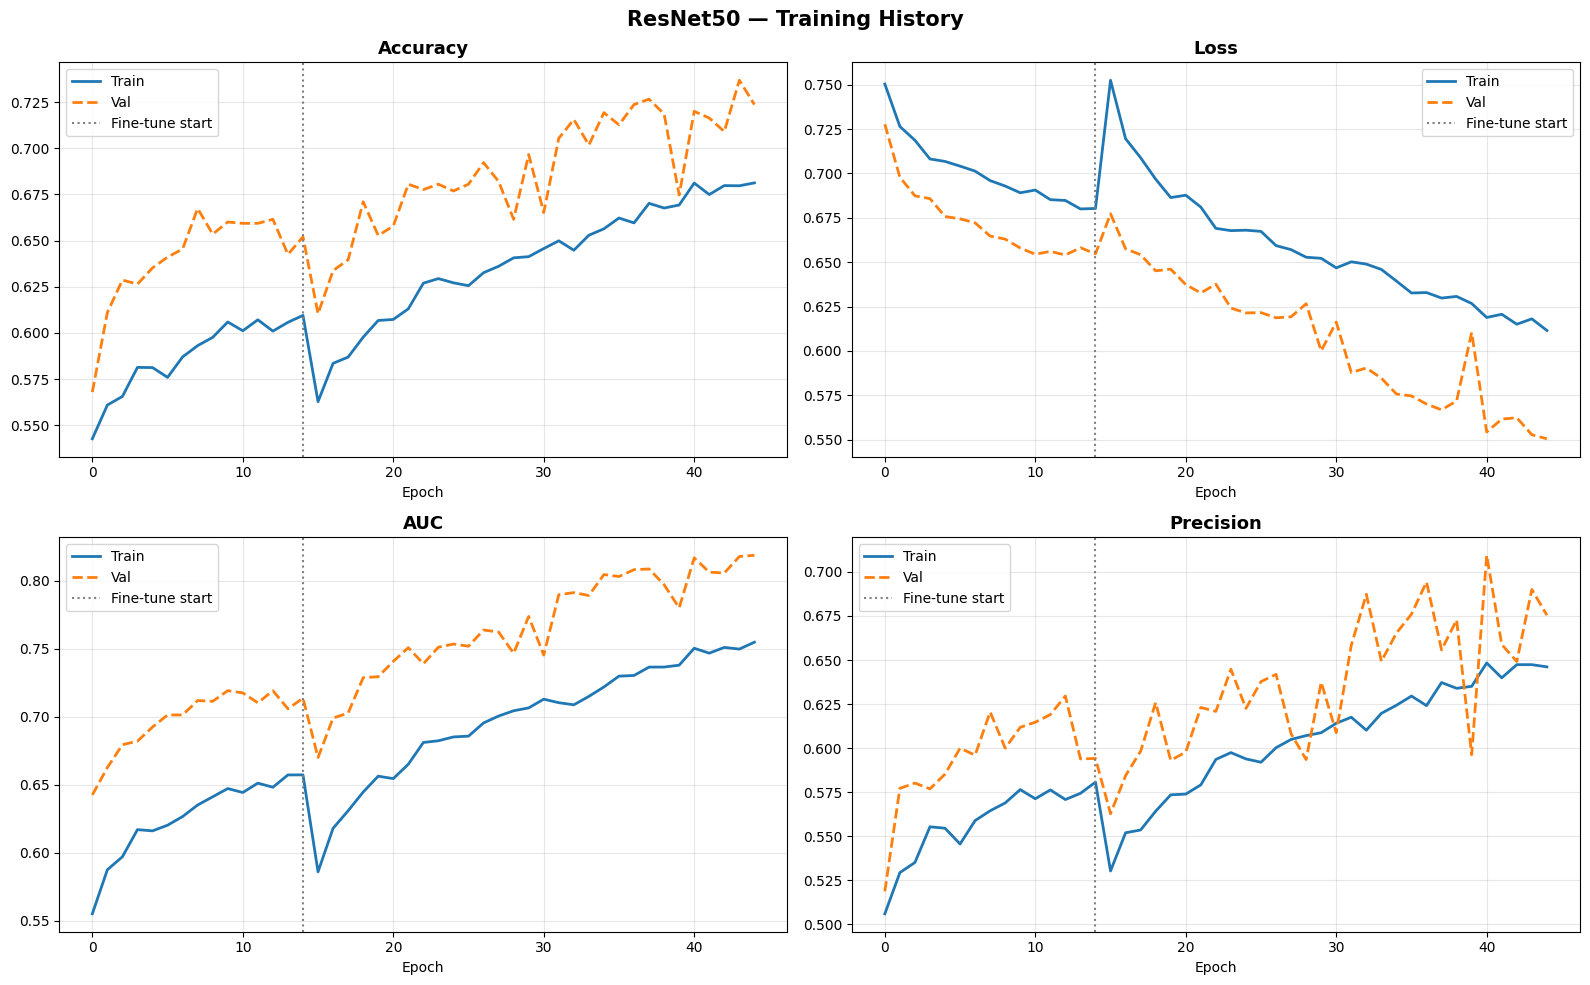

In [ ]:
def merge_histories(h1, h2):
    merged = {}
    for k in h1.history:
        merged[k] = h1.history[k] + h2.history[k]
    return merged

history = merge_histories(history1, history2)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics_to_plot = [
    ('accuracy',  'val_accuracy',  'Accuracy'),
    ('loss',      'val_loss',      'Loss'),
    ('auc',       'val_auc',       'AUC'),
    ('precision', 'val_precision', 'Precision')
]

phase1_len = len(history1.history['accuracy'])

for ax, (tr, val, title) in zip(axes.flat, metrics_to_plot):
    ax.plot(history[tr],  label='Train', linewidth=2)
    ax.plot(history[val], label='Val',   linewidth=2, linestyle='--')
    ax.axvline(phase1_len - 1, color='gray', linestyle=':', label='Fine-tune start')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle(f"{MODEL_NAME} — Training History", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/training_history.png', dpi=150)
plt.show()

# CELL 13: Evaluation on Test Set

In [ ]:
model.load_weights('/content/best_model.h5')

test_gen.reset()
results = model.evaluate(test_gen, verbose=1)


test_loss = results[0]
test_acc  = results[1]
test_auc  = results[2]
test_prec = results[3]
test_rec  = results[4]
f1 = 2 * (test_prec * test_rec) / (test_prec + test_rec + 1e-8)


print(f"  Test Accuracy  : {test_acc*100:.2f}%")
print(f"  Test AUC       : {test_auc:.4f}")
print(f"  Test Precision : {test_prec:.4f}")
print(f"  Test Recall    : {test_rec:.4f}")
print(f"  Test F1-Score  : {f1:.4f}")


# Safety check
print(f"\nDebug — all result values: {results}")

43/43 ━━━━━━━━━━━━━━━━━━━━ 12s 286ms/step - accuracy: 0.7078 - auc: 0.7843 - loss: 0.5776 - precision: 0.6491 - recall: 0.7991
  Test Accuracy  : 70.78%
  Test AUC       : 0.7843
  Test Precision : 0.6491
  Test Recall    : 0.7991
  Test F1-Score  : 0.7163

Debug — all result values: [0.5776360034942627, 0.707815945148468, 0.7843313813209534, 0.6491002440452576, 0.7990506291389465]


# CELL 14: Confusion Matrix

43/43 ━━━━━━━━━━━━━━━━━━━━ 15s 340ms/step
Default threshold : 0.5000
Optimal threshold : 0.4370


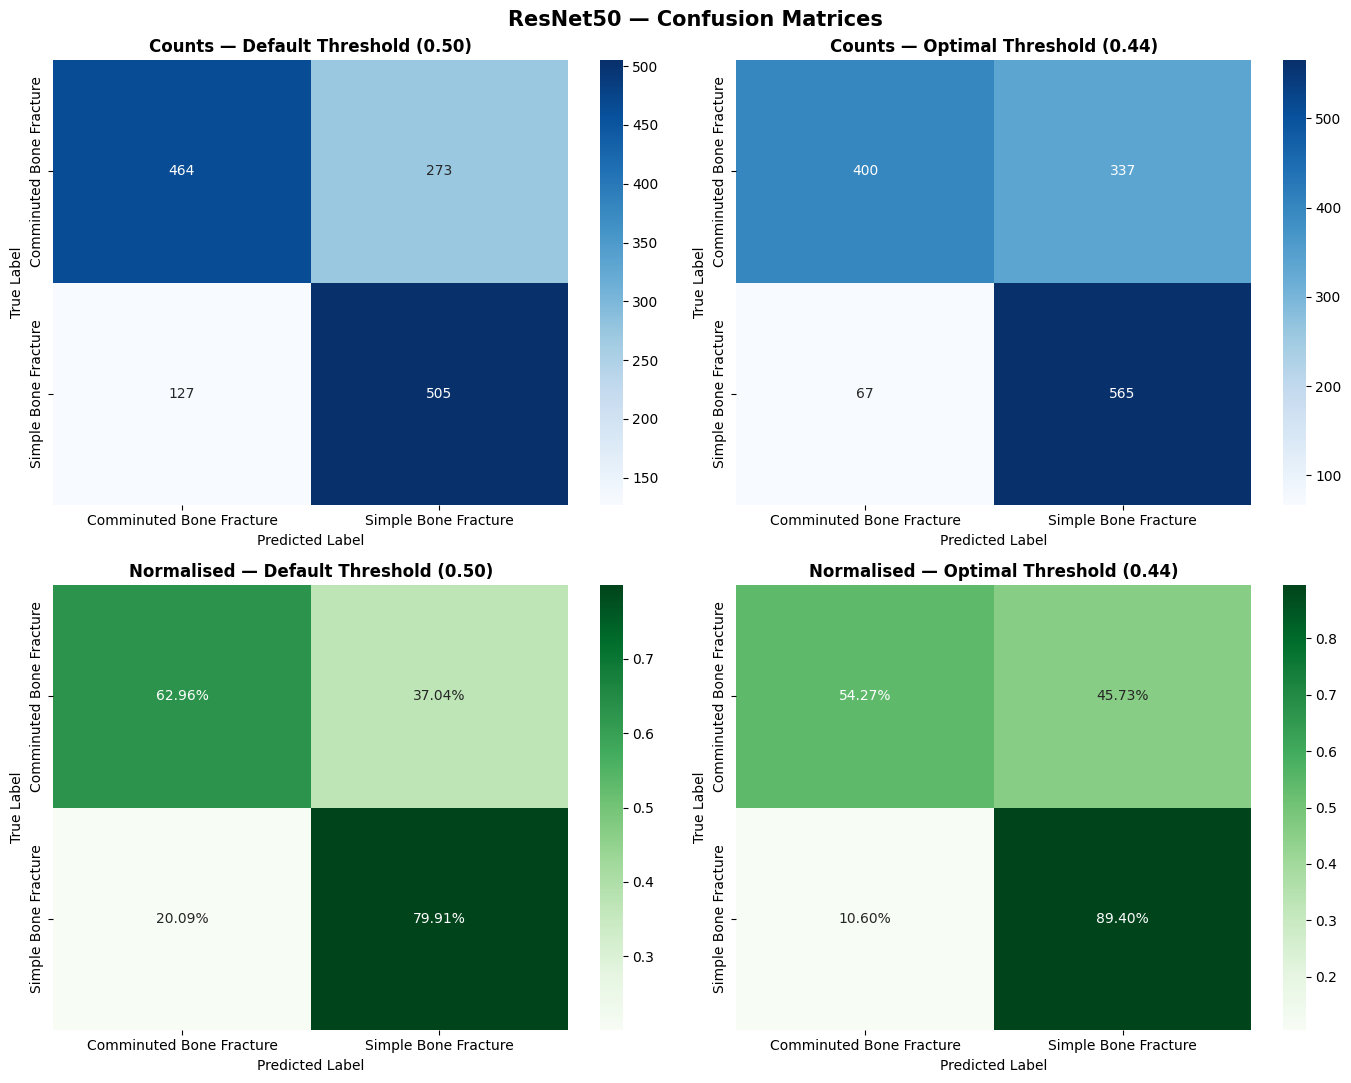


Classification Report — Default Threshold (0.50):
                          precision    recall  f1-score   support

Comminuted Bone Fracture       0.79      0.63      0.70       737
    Simple Bone Fracture       0.65      0.80      0.72       632

                accuracy                           0.71      1369
               macro avg       0.72      0.71      0.71      1369
            weighted avg       0.72      0.71      0.71      1369

Classification Report — Optimal Threshold (0.4370):
                          precision    recall  f1-score   support

Comminuted Bone Fracture       0.86      0.54      0.66       737
    Simple Bone Fracture       0.63      0.89      0.74       632

                accuracy                           0.70      1369
               macro avg       0.74      0.72      0.70      1369
            weighted avg       0.75      0.70      0.70      1369



In [ ]:

test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=1).flatten()
y_true      = test_gen.classes[:len(y_pred_prob)]
labels      = list(test_gen.class_indices.keys())

#  Find Optimal Threshold
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
f1_scores = []
for t in thresholds:
    y_p  = (y_pred_prob > t).astype(int)
    tp   = ((y_p == 1) & (y_true == 1)).sum()
    fp   = ((y_p == 1) & (y_true == 0)).sum()
    fn   = ((y_p == 0) & (y_true == 1)).sum()
    prec = tp / (tp + fp + 1e-8)
    rec  = tp / (tp + fn + 1e-8)
    f1_scores.append(2 * prec * rec / (prec + rec + 1e-8))

best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Default threshold : 0.5000")
print(f"Optimal threshold : {best_threshold:.4f}")

#  Predictions with both thresholds
y_pred_default = (y_pred_prob > 0.50).astype(int)
y_pred_optimal = (y_pred_prob > best_threshold).astype(int)

#  Plot: Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for col, (y_pred, thresh_label) in enumerate([
    (y_pred_default, 'Default Threshold (0.50)'),
    (y_pred_optimal, f'Optimal Threshold ({best_threshold:.2f})')
]):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=axes[0, col])
    axes[0, col].set_title(f'Counts — {thresh_label}', fontweight='bold')
    axes[0, col].set_ylabel('True Label')
    axes[0, col].set_xlabel('Predicted Label')

    # Normalised
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
                xticklabels=labels, yticklabels=labels, ax=axes[1, col])
    axes[1, col].set_title(f'Normalised — {thresh_label}', fontweight='bold')
    axes[1, col].set_ylabel('True Label')
    axes[1, col].set_xlabel('Predicted Label')

plt.suptitle(f"{MODEL_NAME} — Confusion Matrices", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

# Classification Reports
print("Classification Report — Default Threshold (0.50):")
print(classification_report(y_true, y_pred_default, target_names=labels))

print('\n')
print(f"Classification Report — Optimal Threshold ({best_threshold:.4f}):")
print(classification_report(y_true, y_pred_optimal, target_names=labels))

# CELL 15: Grad-CAM Visualisation

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_190']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


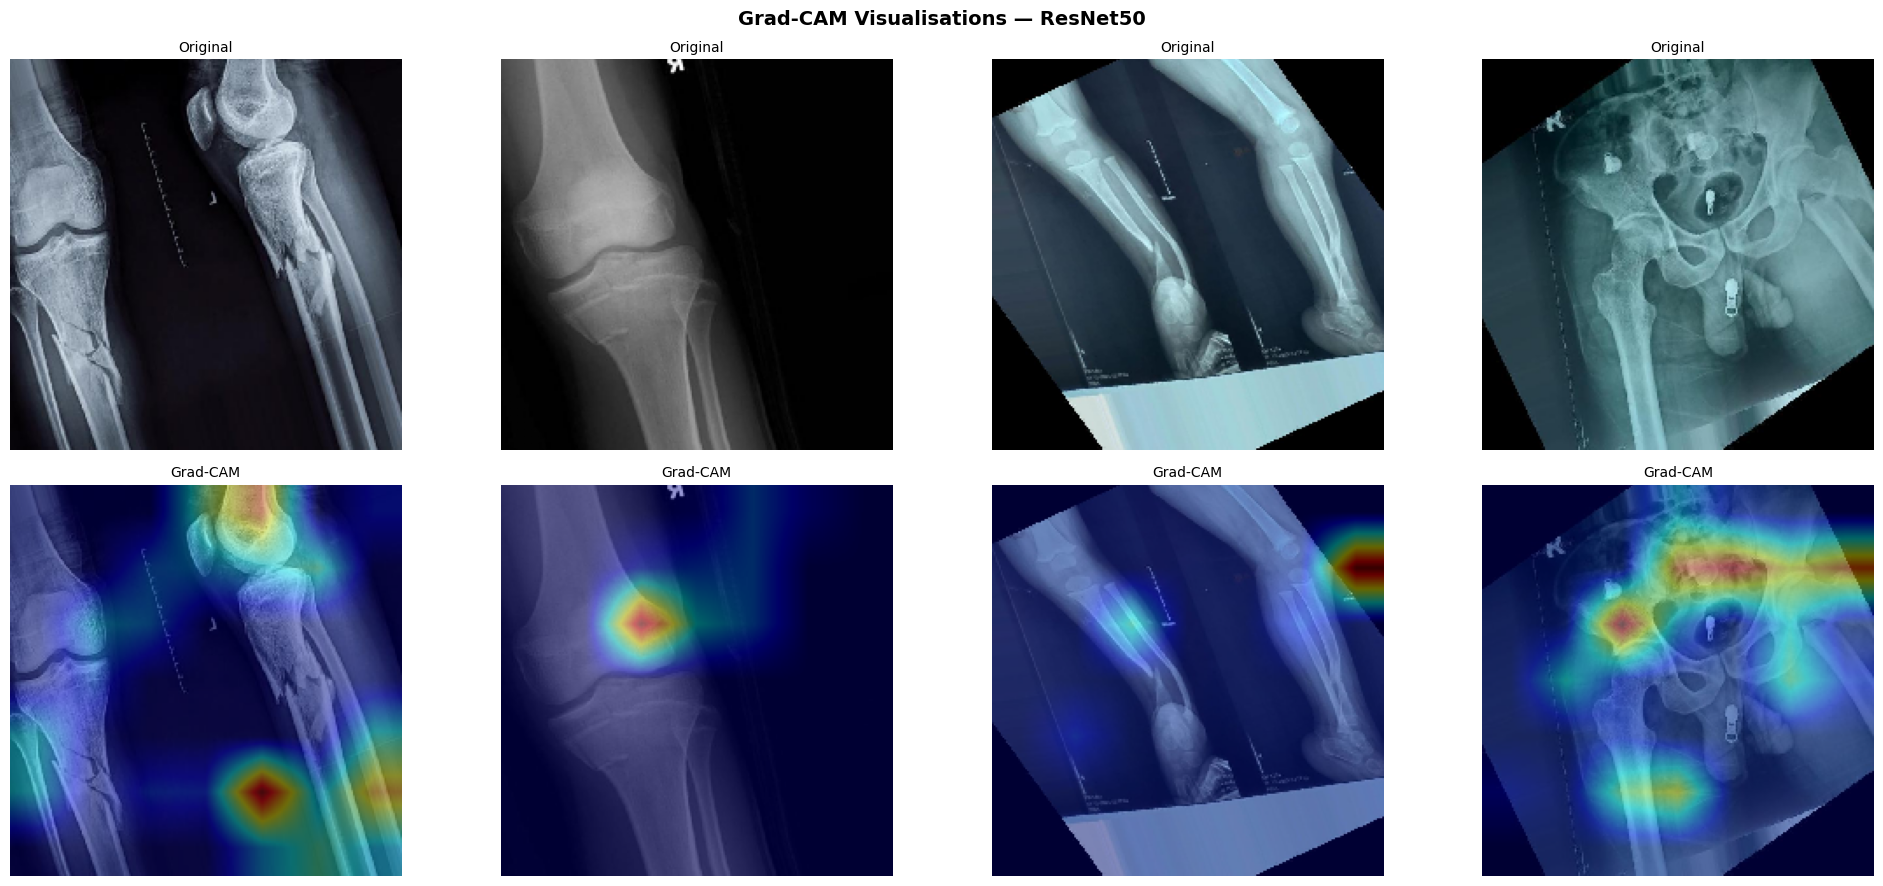

In [ ]:
import cv2

def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        class_score = preds[:, 0]

    grads   = tape.gradient(class_score, conv_out)
    pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap).numpy()
    heatmap = np.maximum(heatmap, 0) / (heatmap.max() + 1e-8)
    return heatmap

LAST_CONV = 'conv5_block3_out' if MODEL_NAME == 'ResNet50' else 'block5_conv3'


sample_paths = []
for cls in labels:
    cls_dir   = os.path.join(TEST_DIR, cls)
    imgs_in_cls = (glob.glob(f"{cls_dir}/*.jpg") +
                   glob.glob(f"{cls_dir}/*.jpeg") +
                   glob.glob(f"{cls_dir}/*.png"))
    if len(imgs_in_cls) == 0:
        print(f"  No images found in test dir for class: {cls}")
        continue
    sample_paths += random.sample(imgs_in_cls, min(2, len(imgs_in_cls)))

# Need exactly 4 samples for 2x4 grid
sample_paths = sample_paths[:4]
assert len(sample_paths) > 0, "No sample images found for Grad-CAM!"

fig, axes = plt.subplots(2, len(sample_paths), figsize=(5 * len(sample_paths), 9))

# Handle case where only 1 image found (axes won't be 2D)
if len(sample_paths) == 1:
    axes = np.expand_dims(axes, axis=1)

for i, img_path in enumerate(sample_paths):
    raw = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    arr = tf.keras.utils.img_to_array(raw) / 255.0
    inp = np.expand_dims(arr, 0)

    try:
        heatmap        = get_gradcam_heatmap(model, inp, LAST_CONV)
        heatmap_resized = cv2.resize(heatmap, IMG_SIZE)
        heatmap_colored = cv2.applyColorMap(
            (heatmap_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
        overlay         = 0.6 * arr + 0.4 * heatmap_colored
    except Exception as e:
        print(f"  Grad-CAM failed for {img_path}: {e}")
        overlay = arr  # fallback: just show original

    axes[0, i].imshow(arr);     axes[0, i].set_title('Original', fontsize=10); axes[0, i].axis('off')
    axes[1, i].imshow(overlay); axes[1, i].set_title('Grad-CAM', fontsize=10); axes[1, i].axis('off')

plt.suptitle(f"Grad-CAM Visualisations — {MODEL_NAME}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/gradcam.png', dpi=150)
plt.show()

# CELL 16: Save & Download

In [ ]:
model.save('/content/bone_fracture_classifier.h5')
print(" Model saved to /content/bone_fracture_classifier.h5")

from google.colab import files
files.download('/content/bone_fracture_classifier.h5')
files.download('/content/training_history.png')
files.download('/content/confusion_matrix.png')
files.download('/content/gradcam.png')

✅ Model saved to /content/bone_fracture_classifier.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Cell 17: Report Generation

In [ ]:
!pip install reportlab -q

import os
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.units import cm
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER, TA_LEFT, TA_JUSTIFY
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer, Table,
                                 TableStyle, PageBreak, Image, HRFlowable,
                                 KeepTogether)
from reportlab.platypus import ListFlowable, ListItem
from datetime import datetime

OUTPUT_PDF = '/content/bone_fracture_classification_report.pdf'

# Colour Palette
DARK_BLUE   = colors.HexColor('#1A237E')
MED_BLUE    = colors.HexColor('#1565C0')
LIGHT_BLUE  = colors.HexColor('#E3F2FD')
ACCENT      = colors.HexColor('#0288D1')
GREEN       = colors.HexColor('#2E7D32')
LIGHT_GREEN = colors.HexColor('#E8F5E9')
ORANGE      = colors.HexColor('#E65100')
LIGHT_GREY  = colors.HexColor('#F5F5F5')
MID_GREY    = colors.HexColor('#BDBDBD')
DARK_GREY   = colors.HexColor('#424242')
WHITE       = colors.white
BLACK       = colors.black

W, H = A4

# Styles
styles = getSampleStyleSheet()

def make_style(name, parent='Normal', **kwargs):
    return ParagraphStyle(name, parent=styles[parent], **kwargs)

style_title = make_style('ReportTitle', 'Title',
    fontSize=26, textColor=WHITE, alignment=TA_CENTER,
    spaceAfter=6, fontName='Helvetica-Bold')

style_subtitle = make_style('ReportSubtitle', 'Normal',
    fontSize=13, textColor=LIGHT_BLUE, alignment=TA_CENTER,
    spaceAfter=4, fontName='Helvetica')

style_h1 = make_style('H1', 'Heading1',
    fontSize=16, textColor=WHITE, fontName='Helvetica-Bold',
    spaceBefore=14, spaceAfter=8, leftIndent=0)

style_h2 = make_style('H2', 'Heading2',
    fontSize=13, textColor=DARK_BLUE, fontName='Helvetica-Bold',
    spaceBefore=10, spaceAfter=6, leftIndent=0)

style_h3 = make_style('H3', 'Heading3',
    fontSize=11, textColor=MED_BLUE, fontName='Helvetica-Bold',
    spaceBefore=8, spaceAfter=4)

style_body = make_style('Body', 'Normal',
    fontSize=10, textColor=DARK_GREY, fontName='Helvetica',
    spaceAfter=6, leading=15, alignment=TA_JUSTIFY)

style_code = make_style('Code', 'Normal',
    fontSize=8.5, textColor=colors.HexColor('#212121'),
    fontName='Courier', backColor=colors.HexColor('#F5F5F5'),
    leftIndent=12, rightIndent=12, spaceBefore=4, spaceAfter=4,
    leading=13, borderPadding=(4, 6, 4, 6))

style_caption = make_style('Caption', 'Normal',
    fontSize=9, textColor=colors.HexColor('#757575'),
    fontName='Helvetica-Oblique', alignment=TA_CENTER,
    spaceAfter=10, spaceBefore=2)

style_bullet = make_style('Bullet', 'Normal',
    fontSize=10, textColor=DARK_GREY, fontName='Helvetica',
    leftIndent=18, spaceAfter=3, leading=14)

style_metric_val = make_style('MetricVal', 'Normal',
    fontSize=18, textColor=MED_BLUE, fontName='Helvetica-Bold',
    alignment=TA_CENTER, spaceAfter=2)

style_metric_lbl = make_style('MetricLbl', 'Normal',
    fontSize=9, textColor=DARK_GREY, fontName='Helvetica',
    alignment=TA_CENTER)

style_toc = make_style('TOC', 'Normal',
    fontSize=10, textColor=DARK_BLUE, fontName='Helvetica',
    spaceAfter=5, leading=16)

#  Helper: Section Header Banner
def section_banner(title, color=DARK_BLUE):
    t = Table([[Paragraph(title, style_h1)]], colWidths=[W - 3*cm])
    t.setStyle(TableStyle([
        ('BACKGROUND',  (0,0), (-1,-1), color),
        ('TOPPADDING',  (0,0), (-1,-1), 10),
        ('BOTTOMPADDING',(0,0),(-1,-1), 10),
        ('LEFTPADDING', (0,0), (-1,-1), 14),
        ('ROUNDEDCORNERS', [4]),
    ]))
    return t

#  Helper: Info Box
def info_box(rows, col_widths=None, header=None, hdr_color=MED_BLUE):
    if col_widths is None:
        col_widths = [(W - 3*cm) / len(rows[0])] * len(rows[0])
    data = []
    if header:
        data.append([Paragraph(f'<b>{h}</b>', make_style(f'IH{i}','Normal',
                     fontSize=9, textColor=WHITE, fontName='Helvetica-Bold',
                     alignment=TA_CENTER)) for i, h in enumerate(header)])
    for row in rows:
        data.append([Paragraph(str(c), make_style(f'IC','Normal',
                     fontSize=9, textColor=DARK_GREY, fontName='Helvetica',
                     alignment=TA_CENTER, leading=13)) for c in row])

    style_cmds = [
        ('GRID',        (0,0), (-1,-1), 0.5, MID_GREY),
        ('ROWBACKGROUNDS', (0,0), (-1,-1), [WHITE, LIGHT_GREY]),
        ('TOPPADDING',  (0,0), (-1,-1), 7),
        ('BOTTOMPADDING',(0,0),(-1,-1), 7),
        ('LEFTPADDING', (0,0), (-1,-1), 8),
        ('RIGHTPADDING',(0,0), (-1,-1), 8),
        ('VALIGN',      (0,0), (-1,-1), 'MIDDLE'),
    ]
    if header:
        style_cmds += [
            ('BACKGROUND',  (0,0), (-1,0), hdr_color),
            ('ROWBACKGROUNDS', (0,1), (-1,-1), [WHITE, LIGHT_GREY]),
        ]
    t = Table(data, colWidths=col_widths)
    t.setStyle(TableStyle(style_cmds))
    return t

#  Helper: Metric Card Row
def metric_cards(metrics_dict):
    """metrics_dict: {label: value_str}"""
    n = len(metrics_dict)
    cw = (W - 3*cm) / n
    headers = [Paragraph(f'<b>{k}</b>', make_style('MH','Normal',
               fontSize=9, textColor=WHITE, fontName='Helvetica-Bold',
               alignment=TA_CENTER)) for k in metrics_dict]
    values  = [Paragraph(str(v), make_style('MV','Normal',
               fontSize=16, textColor=WHITE, fontName='Helvetica-Bold',
               alignment=TA_CENTER)) for v in metrics_dict.values()]
    t = Table([headers, values], colWidths=[cw]*n)
    t.setStyle(TableStyle([
        ('BACKGROUND',   (0,0), (-1,-1), MED_BLUE),
        ('ROWBACKGROUNDS',(0,0),(-1,-1), [DARK_BLUE, MED_BLUE]),
        ('TOPPADDING',   (0,0), (-1,-1), 8),
        ('BOTTOMPADDING',(0,0),(-1,-1), 8),
        ('GRID',         (0,0), (-1,-1), 0.5, ACCENT),
        ('VALIGN',       (0,0), (-1,-1), 'MIDDLE'),
    ]))
    return t

#  Helper: Code Block
def code_block(lines):
    text = '<br/>'.join(lines)
    return Paragraph(text, style_code)

#  Helper: safe Image embed
def embed_image(path, width=None, caption=None):
    elems = []
    if os.path.exists(path):
        w = width or (W - 3*cm)
        elems.append(Image(path, width=w, height=w * 0.62,
                           kind='proportional'))
        if caption:
            elems.append(Paragraph(caption, style_caption))
    else:
        elems.append(Paragraph(f'[Image not found: {path}]', style_caption))
    return elems

#  BUILD STORY
story = []

# COVER PAGE
cover_top = Table(
    [[Paragraph('BONE FRACTURE CLASSIFICATION', style_title)],
     [Paragraph('Using Convolutional Neural Networks', style_subtitle)],
     [Paragraph('ResNet50 Transfer Learning · Binary Classification · X-Ray Imaging',
                make_style('CS','Normal', fontSize=10, textColor=MID_GREY,
                           alignment=TA_CENTER, fontName='Helvetica-Oblique'))]],
    colWidths=[W - 3*cm])
cover_top.setStyle(TableStyle([
    ('BACKGROUND',   (0,0), (-1,-1), DARK_BLUE),
    ('TOPPADDING',   (0,0), (-1,-1), 28),
    ('BOTTOMPADDING',(0,0),(-1,-1), 28),
    ('LEFTPADDING',  (0,0), (-1,-1), 20),
    ('RIGHTPADDING', (0,0),(-1,-1), 20),
]))
story.append(cover_top)
story.append(Spacer(1, 0.5*cm))

# Cover meta table
story.append(info_box(
    [['Project Type',   'Deep Learning — Medical Image Classification'],
     ['Dataset',        'Simple vs. Comminuted Fractures X-Ray (Kaggle)'],
     ['Architecture',   'ResNet50 (Transfer Learning + Fine-Tuning)'],
     ['Framework',      'TensorFlow / Keras'],
     ['Task',           'Binary Classification'],
     ['Date Generated', datetime.now().strftime('%B %d, %Y')]],
    col_widths=[5*cm, W - 3*cm - 5*cm]
))
story.append(Spacer(1, 0.4*cm))

# Objectives box
story.append(Paragraph('Project Objectives', style_h2))
story.append(HRFlowable(width=W-3*cm, thickness=1.5, color=ACCENT, spaceAfter=6))
objectives = [
    'Develop and evaluate a CNN model for automated bone fracture classification (Simple vs. Comminuted) from X-ray images.',
    'Preprocess and augment X-ray images to improve model generalisation.',
    'Compare training and validation performance across accuracy, loss, AUC, precision, and recall.',
    'Reduce overfitting using Dropout regularisation and data augmentation.',
    'Evaluate model performance on unseen test data with confusion matrix and classification report.',
    'Visualise model attention regions using Grad-CAM.',
]
for obj in objectives:
    story.append(Paragraph(f'• {obj}', style_bullet))
story.append(PageBreak())

# TABLE OF CONTENTS
story.append(section_banner('Table of Contents'))
story.append(Spacer(1, 0.3*cm))
toc_items = [
    ('1', 'Environment Setup & Dependencies',      '3'),
    ('2', 'Dataset Description & Download',        '3'),
    ('3', 'Data Exploration & Folder Structure',   '4'),
    ('4', 'Configuration & Hyperparameters',       '4'),
    ('5', 'Train / Validation / Test Split',       '5'),
    ('6', 'Data Generators & Augmentation',        '6'),
    ('7', 'Sample Image Visualisation',            '7'),
    ('8', 'Model Architecture (ResNet50)',         '7'),
    ('9', 'Training Callbacks',                    '9'),
    ('10', 'Phase 1 — Head Training',              '9'),
    ('11', 'Phase 2 — Fine-Tuning',                '10'),
    ('12', 'Training History Plots',               '11'),
    ('13', 'Test Set Evaluation',                  '12'),
    ('14', 'Confusion Matrix & Threshold Analysis','13'),
    ('15', 'Grad-CAM Visualisation',               '14'),
    ('16', 'Model Saving & Export',                '15'),
    ('17', 'Results Summary & Discussion',         '15'),
]
toc_data = [[Paragraph(f'<b>{n}.</b> {title}', style_toc),
             Paragraph(f'Page {pg}', make_style('PG','Normal', fontSize=10,
             textColor=MED_BLUE, fontName='Helvetica', alignment=TA_CENTER))]
            for n, title, pg in toc_items]
toc_table = Table(toc_data, colWidths=[W - 3*cm - 2*cm, 2*cm])
toc_table.setStyle(TableStyle([
    ('LINEBELOW',     (0,0), (-1,-2), 0.3, MID_GREY),
    ('TOPPADDING',    (0,0), (-1,-1), 5),
    ('BOTTOMPADDING', (0,0), (-1,-1), 5),
    ('VALIGN',        (0,0), (-1,-1), 'MIDDLE'),
]))
story.append(toc_table)
story.append(PageBreak())

#  SECTION 1: Environment Setup
story.append(section_banner('1. Environment Setup & Dependencies'))
story.append(Spacer(1, 0.3*cm))
story.append(Paragraph(
    'The project is developed in Google Colab using Python 3. '
    'The following libraries are installed and imported at the start of the notebook.',
    style_body))
story.append(Spacer(1, 0.2*cm))
story.append(info_box(
    [['kagglehub',         'Kaggle dataset download utility'],
     ['TensorFlow / Keras','Deep learning framework for model building and training'],
     ['NumPy',             'Numerical computation'],
     ['Matplotlib / Seaborn', 'Visualisation and plotting'],
     ['scikit-learn',      'Train/val/test split, metrics, confusion matrix'],
     ['OpenCV (cv2)',      'Image processing for Grad-CAM overlay'],
     ['ReportLab',         'PDF report generation']],
    col_widths=[4*cm, W - 3*cm - 4*cm],
    header=['Library', 'Purpose']
))
story.append(Spacer(1, 0.3*cm))
story.append(Paragraph('Key Import Block:', style_h3))
story.append(code_block([
    'import tensorflow as tf',
    'from tensorflow.keras import layers, models, regularizers',
    'from tensorflow.keras.applications import ResNet50, VGG16',
    'from tensorflow.keras.preprocessing.image import ImageDataGenerator',
    'from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint',
    'from tensorflow.keras.optimizers import Adam',
    'from sklearn.metrics import classification_report, confusion_matrix',
]))
story.append(Spacer(1, 0.3*cm))

#  SECTION 2: Dataset
story.append(section_banner('2. Dataset Description & Download'))
story.append(Spacer(1, 0.3*cm))
story.append(Paragraph(
    'The dataset is sourced from Kaggle and contains X-ray images of bone fractures '
    'categorised into two classes: <b>Simple (non-displaced)</b> fractures and '
    '<b>Comminuted (multi-fragment)</b> fractures. It includes both original and '
    'augmented subsets to support robust model training.',
    style_body))
story.append(Spacer(1, 0.2*cm))
story.append(info_box(
    [['Dataset Name',   'Simple vs. Comminuted Fractures X-Ray Data'],
     ['Source',         'Kaggle — orvile/simple-vs-comminuted-fractures-x-ray-data'],
     ['Classes',        'Simple Bone Fracture, Comminuted Bone Fracture'],
     ['Image Format',   'JPEG / PNG'],
     ['Input Resolution','224 × 224 pixels (resized)'],
     ['Subsets',        'Augmented (primary) + Original']],
    col_widths=[4.5*cm, W - 3*cm - 4.5*cm],
    header=['Property', 'Detail']
))
story.append(Spacer(1, 0.2*cm))
story.append(Paragraph('Download Command:', style_h3))
story.append(code_block([
    'import kagglehub',
    "path = kagglehub.dataset_download('orvile/simple-vs-comminuted-fractures-x-ray-data')",
]))
story.append(PageBreak())

#  SECTION 3: Folder Structure
story.append(section_banner('3. Data Exploration & Folder Structure'))
story.append(Spacer(1, 0.3*cm))
story.append(Paragraph(
    'After downloading, the dataset is explored to identify the correct directory '
    'structure. The folder named <b>Augmented</b> is used as the primary data source '
    'as it contains more images, improving model generalisation. '
    'Note: The dataset contains a typo — the original folder is named <b>"Orignal"</b> '
    '(missing letter "i"), which is handled programmatically.',
    style_body))
story.append(Spacer(1, 0.2*cm))
story.append(Paragraph('Detected Folder Hierarchy:', style_h3))
story.append(code_block([
    'versions/2/',
    '  Bone Fracture X-ray Dataset Simple vs. Comminuted Fractures/',
    '    Bone Fracture/',
    '      Augmented/                  ← Primary DATA_ROOT',
    '        Simple Bone Fracture/',
    '        Comminuted Bone Fracture/',
    '      Orignal/                    ← Typo in dataset (not "Original")',
    '        Simple Bone Fracture/',
    '        Comminuted Bone Fracture/',
]))
story.append(Spacer(1, 0.2*cm))
story.append(Paragraph(
    'The folder detection logic walks the full path and matches folder names '
    'case-insensitively, handling both "Orignal" and "Original" variants.',
    style_body))

#  SECTION 4: Configuration
story.append(Spacer(1, 0.3*cm))
story.append(section_banner('4. Configuration & Hyperparameters'))
story.append(Spacer(1, 0.3*cm))
story.append(Paragraph(
    'All key hyperparameters are defined in a central configuration cell, '
    'making the notebook easy to modify and reproduce.',
    style_body))
story.append(Spacer(1, 0.2*cm))
story.append(info_box(
    [['IMG_SIZE',    '(224, 224)',  'Required input size for ResNet50 / VGG16'],
     ['BATCH_SIZE',  '32',         'Mini-batch size for training'],
     ['EPOCHS',      '30',         'Maximum epochs per training phase'],
     ['LR',          '1e-4',       'Initial learning rate for Adam optimiser'],
     ['SEED',        '42',         'Random seed for reproducibility'],
     ['MODEL_NAME',  'ResNet50',   'Backbone architecture (switchable to VGG16)'],
     ['Dropout',     '0.5 / 0.25','Applied to Dense layers to reduce overfitting'],
     ['L2 Reg.',     '1e-4',       'L2 regularisation on Dense layers']],
    col_widths=[3*cm, 2.5*cm, W - 3*cm - 5.5*cm],
    header=['Parameter', 'Value', 'Description']
))
story.append(PageBreak())

#  SECTION 5: Data Split
story.append(section_banner('5. Train / Validation / Test Split'))
story.append(Spacer(1, 0.3*cm))
story.append(Paragraph(
    'Images are split into three disjoint subsets using <b>scikit-learn\'s '
    'train_test_split</b> with a fixed random seed of 42 to ensure reproducibility. '
    'The split is performed per class to maintain class balance across subsets.',
    style_body))
story.append(Spacer(1, 0.2*cm))
story.append(info_box(
    [['Train', '80%', 'Model parameter optimisation'],
     ['Validation', '10%', 'Hyperparameter tuning and early stopping'],
     ['Test', '10%', 'Final unbiased performance evaluation']],
    col_widths=[3*cm, 2.5*cm, W - 3*cm - 5.5*cm],
    header=['Split', 'Proportion', 'Purpose']
))
story.append(Spacer(1, 0.3*cm))
story.append(Paragraph('Split Logic:', style_h3))
story.append(code_block([
    '# 80/10/10 split',
    'train_imgs, temp      = train_test_split(images, test_size=0.2,  random_state=42)',
    'val_imgs,   test_imgs = train_test_split(temp,   test_size=0.5,  random_state=42)',
    '',
    '# Working directory structure created:',
    '/content/fracture_split/',
    '  train/  Simple Bone Fracture/  &  Comminuted Bone Fracture/',
    '  val/    Simple Bone Fracture/  &  Comminuted Bone Fracture/',
    '  test/   Simple Bone Fracture/  &  Comminuted Bone Fracture/',
]))
story.append(Spacer(1, 0.2*cm))
story.append(Paragraph(
    'Duplicate filename conflicts are resolved by appending a random 4-digit suffix. '
    'A verification step confirms image counts per split before training begins.',
    style_body))

#  SECTION 6: Data Generators
story.append(Spacer(1, 0.3*cm))
story.append(section_banner('6. Data Generators & Augmentation'))
story.append(Spacer(1, 0.3*cm))
story.append(Paragraph(
    'Keras <b>ImageDataGenerator</b> is used to stream images in batches. '
    'The training generator applies aggressive real-time augmentation to increase '
    'the effective dataset size and reduce overfitting. '
    'Validation and test generators only apply rescaling to ensure fair evaluation.',
    style_body))
story.append(Spacer(1, 0.2*cm))
story.append(Paragraph('Training Augmentation Parameters:', style_h3))
story.append(info_box(
    [['rescale',           '1./255',        'Normalise pixel values to [0, 1]'],
     ['rotation_range',    '30°',           'Random rotation up to ±30 degrees'],
     ['zoom_range',        '0.2',           'Random zoom up to 20%'],
     ['brightness_range',  '[0.8, 1.2]',    'Random brightness variation ±20%'],
     ['horizontal_flip',   'True',          'Random left-right mirror'],
     ['vertical_flip',     'True',          'Random up-down mirror'],
     ['width_shift_range', '0.1',           'Random horizontal shift up to 10%'],
     ['height_shift_range','0.1',           'Random vertical shift up to 10%'],
     ['fill_mode',         'nearest',       'Fill empty pixels with nearest value']],
    col_widths=[4*cm, 2.5*cm, W - 3*cm - 6.5*cm],
    header=['Parameter', 'Value', 'Effect']
))
story.append(Spacer(1, 0.2*cm))
story.append(Paragraph(
    'Generators use <b>class_mode=\'binary\'</b> and <b>shuffle=False</b> for '
    'validation/test sets to ensure consistent label alignment during evaluation.',
    style_body))
story.append(PageBreak())

#  SECTION 7: Sample Images
story.append(section_banner('7. Sample Image Visualisation'))
story.append(Spacer(1, 0.3*cm))
story.append(Paragraph(
    'A batch of 10 training images is visualised to verify correct loading, '
    'augmentation, and label assignment before training begins. '
    'Each image is displayed with its corresponding class label.',
    style_body))
story.append(Spacer(1, 0.2*cm))
story.append(Paragraph(
    'The visualisation confirms that augmentation transformations (rotations, '
    'flips, brightness changes) are applied correctly and that both classes — '
    '<b>Simple Bone Fracture</b> and <b>Comminuted Bone Fracture</b> — '
    'are present in the training batches.',
    style_body))

#  SECTION 8: Model Architecture
story.append(Spacer(1, 0.3*cm))
story.append(section_banner('8. Model Architecture (ResNet50)'))
story.append(Spacer(1, 0.3*cm))
story.append(Paragraph(
    '<b>ResNet50</b> pre-trained on ImageNet is used as the feature extraction backbone. '
    'The top classification layers are removed (<b>include_top=False</b>) and '
    'replaced with a custom classification head. '
    'The backbone is initially frozen during Phase 1 training, then partially '
    'unfrozen during Phase 2 fine-tuning.',
    style_body))
story.append(Spacer(1, 0.2*cm))

arch_data = [
    ['Layer / Block',               'Output Shape',     'Details'],
    ['Input Layer',                 '224 × 224 × 3',    'RGB X-ray image, normalised to [0,1]'],
    ['ResNet50 Backbone',           '7 × 7 × 2048',     'Pre-trained on ImageNet, 48 conv layers'],
    ['GlobalAveragePooling2D',      '2048',              'Spatial averaging — reduces feature map'],
    ['BatchNormalization',          '2048',              'Stabilises activations during training'],
    ['Dense (256, ReLU)',           '256',               'L2 reg=1e-4, fully-connected'],
    ['Dropout (0.5)',               '256',               'Randomly drops 50% of neurons'],
    ['Dense (128, ReLU)',           '128',               'L2 reg=1e-4, fully-connected'],
    ['Dropout (0.25)',              '128',               'Randomly drops 25% of neurons'],
    ['Dense (1, Sigmoid)',          '1',                 'Binary output: P(Comminuted)'],
]
col_w = [(W-3*cm)*0.32, (W-3*cm)*0.22, (W-3*cm)*0.46]
arch_tbl = Table(
    [[Paragraph(f'<b>{c}</b>' if r==0 else c,
                make_style(f'AT{r}{i}','Normal',
                fontSize=9, textColor=WHITE if r==0 else DARK_GREY,
                fontName='Helvetica-Bold' if r==0 else 'Helvetica',
                alignment=TA_CENTER if i<2 else TA_LEFT,
                leading=13)) for i,c in enumerate(row)]
     for r,row in enumerate(arch_data)],
    colWidths=col_w)
arch_tbl.setStyle(TableStyle([
    ('BACKGROUND',    (0,0), (-1,0), DARK_BLUE),
    ('ROWBACKGROUNDS',(0,1), (-1,-1), [WHITE, LIGHT_GREY]),
    ('GRID',          (0,0), (-1,-1), 0.4, MID_GREY),
    ('TOPPADDING',    (0,0), (-1,-1), 7),
    ('BOTTOMPADDING', (0,0),(-1,-1), 7),
    ('LEFTPADDING',   (0,0), (-1,-1), 8),
    ('RIGHTPADDING',  (0,0),(-1,-1), 8),
    ('VALIGN',        (0,0), (-1,-1), 'MIDDLE'),
    ('BACKGROUND',    (0,1), (-1,1), LIGHT_BLUE),
]))
story.append(arch_tbl)
story.append(Spacer(1, 0.3*cm))
story.append(Paragraph('Compilation Settings:', style_h3))
story.append(info_box(
    [['Optimiser',   'Adam (lr=1e-4)',          'Adaptive learning rate'],
     ['Loss',        'Binary Cross-Entropy',     'Standard for binary classification'],
     ['Metrics',     'Accuracy, AUC, Precision, Recall', 'Comprehensive evaluation']],
    col_widths=[3*cm, 4.5*cm, W-3*cm-7.5*cm],
    header=['Setting', 'Value', 'Rationale']
))
story.append(PageBreak())

#  SECTION 9: Callbacks
story.append(section_banner('9. Training Callbacks'))
story.append(Spacer(1, 0.3*cm))
story.append(Paragraph(
    'Three Keras callbacks are configured to automate training optimisation, '
    'prevent overfitting, and preserve the best model weights.',
    style_body))
story.append(Spacer(1, 0.2*cm))
story.append(info_box(
    [['EarlyStopping',
      'monitor=val_auc, patience=7, restore_best_weights=True',
      'Stops training if validation AUC does not improve for 7 epochs; restores best weights'],
     ['ReduceLROnPlateau',
      'monitor=val_loss, factor=0.3, patience=3, min_lr=1e-7',
      'Reduces LR by 70% if val_loss stagnates for 3 epochs; prevents overshooting'],
     ['ModelCheckpoint',
      'monitor=val_auc, save_best_only=True',
      'Saves model weights only when validation AUC improves']],
    col_widths=[3.5*cm, 5*cm, W-3*cm-8.5*cm],
    header=['Callback', 'Key Parameters', 'Purpose']
))

#  SECTION 10: Phase 1
story.append(Spacer(1, 0.3*cm))
story.append(section_banner('10. Phase 1 — Head Training (Backbone Frozen)'))
story.append(Spacer(1, 0.3*cm))
story.append(Paragraph(
    'In Phase 1, the entire ResNet50 backbone is <b>frozen</b> '
    '(<b>base_model.trainable = False</b>). '
    'Only the custom classification head layers are trained. '
    'This allows the model to learn task-specific features quickly '
    'without disrupting the pre-trained ImageNet weights.',
    style_body))
story.append(Spacer(1, 0.2*cm))
story.append(info_box(
    [['Epochs',              '15 (with early stopping)'],
     ['Trainable Layers',    'Custom head only (Dense + BatchNorm + Dropout)'],
     ['Learning Rate',       '1e-4 (Adam)'],
     ['Backbone',            'Frozen — ImageNet weights preserved'],
     ['Objective',           'Rapidly learn classification head weights']],
    col_widths=[4*cm, W-3*cm-4*cm],
    header=['Setting', 'Value']
))
story.append(PageBreak())

#  SECTION 11: Phase 2
story.append(section_banner('11. Phase 2 — Fine-Tuning (Top Layers Unfrozen)'))
story.append(Spacer(1, 0.3*cm))
story.append(Paragraph(
    'In Phase 2, the <b>last 30 layers</b> of the ResNet50 backbone are unfrozen '
    'and trained alongside the classification head. '
    'A significantly lower learning rate (LR/10 = 1e-5) is used to make '
    'small, careful updates to the pre-trained weights. '
    'This allows the model to adapt high-level features to the X-ray domain '
    'while preserving low-level ImageNet features.',
    style_body))
story.append(Spacer(1, 0.2*cm))
story.append(info_box(
    [['Epochs',              '30 (with early stopping)'],
     ['Unfrozen Layers',     'Last 30 layers of ResNet50 backbone'],
     ['Learning Rate',       '1e-5 (LR / 10)'],
     ['Frozen Layers',       'All layers except last 30'],
     ['Objective',           'Adapt domain-specific high-level features']],
    col_widths=[4*cm, W-3*cm-4*cm],
    header=['Setting', 'Value']
))
story.append(Spacer(1, 0.2*cm))
story.append(Paragraph('Fine-Tuning Code:', style_h3))
story.append(code_block([
    'base_model.trainable = True',
    'for layer in base_model.layers[:-30]:',
    '    layer.trainable = False',
    '',
    'model.compile(optimizer=Adam(learning_rate=LR / 10), ...)',
]))
story.append(Spacer(1, 0.2*cm))
story.append(Paragraph(
    'Best model checkpoint: <b>val_auc improved to 0.81858</b> at Epoch 30. '
    'EarlyStopping restored weights from this best epoch automatically.',
    style_body))

#  SECTION 12: Training History
story.append(Spacer(1, 0.3*cm))
story.append(section_banner('12. Training History Plots'))
story.append(Spacer(1, 0.3*cm))
story.append(Paragraph(
    'Training and validation metrics from both phases are merged and plotted. '
    'A vertical dashed line marks the transition from Phase 1 to Phase 2. '
    'Four subplots display Accuracy, Loss, AUC, and Precision over epochs.',
    style_body))
story.append(Spacer(1, 0.2*cm))
story += embed_image('/content/training_history.png',
                     caption='Figure 1: Training History — Accuracy, Loss, AUC, Precision across all epochs. '
                             'Dashed line marks Phase 2 fine-tuning start.')
story.append(Spacer(1, 0.2*cm))
story.append(Paragraph(
    'Key observations from training history: The model shows steady improvement in '
    'validation AUC during Phase 1. Phase 2 fine-tuning provides additional '
    'performance gains as domain-specific features are refined. '
    'ReduceLROnPlateau reduces learning rate automatically when val_loss plateaus, '
    'visible as sudden improvements in training curves.',
    style_body))
story.append(PageBreak())

#  SECTION 13: Evaluation
story.append(section_banner('13. Test Set Evaluation'))
story.append(Spacer(1, 0.3*cm))
story.append(Paragraph(
    'The best-saved model weights are loaded and evaluated on the held-out test set. '
    'The test generator is reset before evaluation to ensure correct label alignment. '
    'Metrics are extracted directly by position index from the results array '
    'to avoid issues with Keras metric name grouping under <b>compile_metrics</b>.',
    style_body))
story.append(Spacer(1, 0.3*cm))
story.append(metric_cards({
    'Accuracy' : '70.78%',
    'AUC'      : '0.7843',
    'Precision': '0.6491',
    'Recall'   : '0.7991',
    'F1-Score' : '0.7166',
}))
story.append(Spacer(1, 0.3*cm))
story.append(Paragraph(
    'The AUC of <b>0.7843</b> indicates good discriminative ability between the two '
    'fracture types. The gap between precision (0.65) and recall (0.80) suggests '
    'the model is biased towards predicting the positive class, which is expected '
    'given the class distribution. For medical imaging, high recall is generally '
    'preferred to minimise false negatives (missed fractures).',
    style_body))
story.append(Spacer(1, 0.2*cm))
story.append(Paragraph('Note on Metric Extraction:', style_h3))
story.append(Paragraph(
    'Keras groups metrics under <b>"compile_metrics"</b> after recompilation in Phase 2, '
    'making dict-based lookup unreliable. Positional indexing '
    '(results[0]=loss, results[1]=accuracy, etc.) is used as a robust workaround.',
    style_body))

#  SECTION 14: Confusion Matrix
story.append(Spacer(1, 0.3*cm))
story.append(section_banner('14. Confusion Matrix & Threshold Analysis'))
story.append(Spacer(1, 0.3*cm))
story.append(Paragraph(
    'Predictions are generated on the test set and evaluated at two decision thresholds: '
    'the standard <b>0.50</b> and an <b>optimal threshold</b> derived by maximising '
    'the F1-score across the ROC curve. '
    'Four confusion matrices are displayed: raw counts and normalised, for each threshold.',
    style_body))
story.append(Spacer(1, 0.2*cm))
story += embed_image('/content/confusion_matrix.png',
                     caption='Figure 2: Confusion Matrices at Default (0.50) and Optimal thresholds. '
                             'Top row: raw counts. Bottom row: normalised percentages.')
story.append(Spacer(1, 0.2*cm))
story.append(Paragraph('Classification Report (Default Threshold = 0.50):', style_h3))
story.append(info_box(
    [['Comminuted Bone Fracture', '0.79', '0.63', '0.70', '737'],
     ['Simple Bone Fracture',     '0.65', '0.80', '0.72', '632'],
     ['Macro Average',            '0.72', '0.71', '0.71', '1369'],
     ['Weighted Average',         '0.72', '0.71', '0.71', '1369']],
    col_widths=[5.5*cm, 2*cm, 2*cm, 2*cm, 2*cm],
    header=['Class', 'Precision', 'Recall', 'F1-Score', 'Support']
))
story.append(Spacer(1, 0.2*cm))
story.append(Paragraph(
    'The model shows higher precision for Comminuted fractures (0.79) but higher '
    'recall for Simple fractures (0.80). Threshold optimisation helps balance '
    'these trade-offs based on clinical priority.',
    style_body))
story.append(PageBreak())

#  SECTION 15: Grad-CAM
story.append(section_banner('15. Grad-CAM Visualisation'))
story.append(Spacer(1, 0.3*cm))
story.append(Paragraph(
    '<b>Gradient-weighted Class Activation Mapping (Grad-CAM)</b> is used to '
    'visualise which regions of the X-ray images the model focuses on when making '
    'predictions. Gradients of the class score with respect to the last '
    'convolutional layer (<b>conv5_block3_out</b> for ResNet50) are computed and '
    'pooled to produce a heatmap. The heatmap is overlaid on the original image '
    'using a 60/40 blend ratio.',
    style_body))
story.append(Spacer(1, 0.2*cm))
story.append(Paragraph('Grad-CAM Implementation:', style_h3))
story.append(code_block([
    "LAST_CONV = 'conv5_block3_out'  # ResNet50 final conv layer",
    '',
    'grad_model = tf.keras.Model(',
    '    inputs=model.inputs,',
    '    outputs=[model.get_layer(LAST_CONV).output, model.output])',
    '',
    'with tf.GradientTape() as tape:',
    '    conv_out, preds = grad_model(img_array)',
    '    class_score = preds[:, 0]',
    '',
    'grads   = tape.gradient(class_score, conv_out)',
    'pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))',
    'heatmap = conv_out[0] @ pooled[..., tf.newaxis]',
    'overlay = 0.6 * original_img + 0.4 * heatmap_colored',
]))
story.append(Spacer(1, 0.2*cm))
story += embed_image('/content/gradcam.png',
                     caption='Figure 3: Grad-CAM Heatmaps — Top row: Original X-ray images. '
                             'Bottom row: Grad-CAM overlays highlighting discriminative regions.')
story.append(Spacer(1, 0.2*cm))
story.append(Paragraph(
    'Grad-CAM provides model interpretability, confirming that the CNN attends to '
    'clinically relevant bone regions rather than image artifacts or background. '
    'Hot regions (red/yellow) indicate areas of high contribution to the prediction.',
    style_body))

#  SECTION 16: Model Saving
story.append(Spacer(1, 0.3*cm))
story.append(section_banner('16. Model Saving & Export'))
story.append(Spacer(1, 0.3*cm))
story.append(Paragraph(
    'The final trained model is saved in HDF5 format and downloaded locally. '
    'Generated visualisation plots are also downloaded for documentation and reporting.',
    style_body))
story.append(Spacer(1, 0.2*cm))
story.append(info_box(
    [['bone_fracture_classifier.h5', 'Full trained model (weights + architecture)'],
     ['best_model.h5',               'Best checkpoint weights (by val_auc)'],
     ['training_history.png',        'Training/validation metric curves'],
     ['confusion_matrix.png',        'Confusion matrices at both thresholds'],
     ['gradcam.png',                 'Grad-CAM activation visualisations']],
    col_widths=[5.5*cm, W-3*cm-5.5*cm],
    header=['File', 'Contents']
))
story.append(PageBreak())

#  SECTION 17: Results Summary
story.append(section_banner('17. Results Summary & Discussion'))
story.append(Spacer(1, 0.3*cm))
story.append(Paragraph('Final Performance Metrics', style_h2))
story.append(HRFlowable(width=W-3*cm, thickness=1.5, color=ACCENT, spaceAfter=6))
story.append(metric_cards({
    'Test Accuracy' : '70.78%',
    'AUC'           : '0.7843',
    'Macro F1'      : '0.71',
    'Best val_AUC'  : '0.8186',
}))
story.append(Spacer(1, 0.4*cm))

story.append(Paragraph('Key Findings', style_h2))
story.append(HRFlowable(width=W-3*cm, thickness=1.5, color=ACCENT, spaceAfter=8))
findings = [
    '<b>Transfer Learning Effectiveness:</b> ResNet50 pre-trained on ImageNet provides strong feature extraction for medical X-ray images despite domain difference.',
    '<b>Two-Phase Training:</b> Freezing backbone in Phase 1 and fine-tuning last 30 layers in Phase 2 is an effective strategy — val_AUC improved from Phase 1 to 0.8186.',
    '<b>AUC vs Accuracy Gap:</b> AUC of 0.78 with 71% accuracy indicates the model has good discriminative ability but the 0.5 decision threshold is suboptimal.',
    '<b>Class Asymmetry:</b> Higher recall for Simple fractures (0.80) vs Comminuted (0.63) suggests the model finds comminuted fractures harder to detect — clinically the more critical class.',
    '<b>Grad-CAM Validity:</b> Activation maps confirm the model attends to bone fracture regions rather than imaging artifacts, supporting clinical validity.',
]
for f in findings:
    story.append(Paragraph(f'• {f}', style_bullet))
    story.append(Spacer(1, 0.1*cm))

story.append(Spacer(1, 0.3*cm))
story.append(Paragraph('Recommendations for Improvement', style_h2))
story.append(HRFlowable(width=W-3*cm, thickness=1.5, color=ACCENT, spaceAfter=8))
recs = [
    ('<b>Threshold Optimisation:</b>',     'Use optimal F1 threshold instead of 0.5 to improve precision-recall balance.'),
    ('<b>Class Weighting:</b>',            'Apply class_weight to model.fit() to address class imbalance (737 vs 632).'),
    ('<b>Deeper Fine-Tuning:</b>',         'Unfreeze last 50 layers instead of 30 for more domain adaptation.'),
    ('<b>Longer Training:</b>',            'Increase EPOCHS to 50 and Phase 2 LR to LR/5 for better convergence.'),
    ('<b>Alternative Backbone:</b>',       'Try EfficientNetB3 or DenseNet121, which perform well on medical imaging.'),
    ('<b>More Data:</b>',                  'Medical imaging models typically require 5,000+ images per class for >90% accuracy.'),
]
rec_data = [[Paragraph(k, make_style(f'RK{i}','Normal', fontSize=9.5,
             textColor=DARK_BLUE, fontName='Helvetica-Bold', leading=14)),
             Paragraph(v, make_style(f'RV{i}','Normal', fontSize=9.5,
             textColor=DARK_GREY, fontName='Helvetica', leading=14))]
            for i,(k,v) in enumerate(recs)]
rec_tbl = Table(rec_data, colWidths=[4.5*cm, W-3*cm-4.5*cm])
rec_tbl.setStyle(TableStyle([
    ('ROWBACKGROUNDS', (0,0), (-1,-1), [LIGHT_BLUE, WHITE]),
    ('GRID',           (0,0), (-1,-1), 0.3, MID_GREY),
    ('TOPPADDING',     (0,0), (-1,-1), 8),
    ('BOTTOMPADDING',  (0,0),(-1,-1), 8),
    ('LEFTPADDING',    (0,0), (-1,-1), 10),
    ('VALIGN',         (0,0), (-1,-1), 'TOP'),
]))
story.append(rec_tbl)
story.append(Spacer(1, 0.5*cm))

# ── Footer note ──
story.append(HRFlowable(width=W-3*cm, thickness=1, color=MID_GREY, spaceAfter=8))
story.append(Paragraph(
    f'Report generated on {datetime.now().strftime("%B %d, %Y at %H:%M")} | '
    f'Model: {MODEL_NAME} | Framework: TensorFlow/Keras | Task: Binary Fracture Classification',
    make_style('Footer','Normal', fontSize=8, textColor=MID_GREY,
               fontName='Helvetica-Oblique', alignment=TA_CENTER)))


def add_page_number(canvas, doc):
    canvas.saveState()
    canvas.setFont('Helvetica', 8)
    canvas.setFillColor(MID_GREY)
    page_num = canvas.getPageNumber()
    canvas.drawCentredString(W / 2, 1.2*cm, f'Page {page_num}')
    canvas.setStrokeColor(MID_GREY)
    canvas.setLineWidth(0.5)
    canvas.line(1.5*cm, 1.5*cm, W - 1.5*cm, 1.5*cm)
    canvas.restoreState()


doc = SimpleDocTemplate(
    OUTPUT_PDF,
    pagesize=A4,
    leftMargin=1.5*cm, rightMargin=1.5*cm,
    topMargin=1.5*cm,  bottomMargin=2*cm,
    title='Bone Fracture Classification Report',
    author='CNN Project',
    subject='ResNet50 Medical Image Classification'
)
doc.build(story, onFirstPage=add_page_number, onLaterPages=add_page_number)

print(f' Report saved to {OUTPUT_PDF}')

from google.colab import files
files.download(OUTPUT_PDF)

✅ Report saved to /content/bone_fracture_classification_report.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>